# Khám phá Dữ liệu Dân số Toàn cầu (Exploratory Data Analysis - EDA)

Notebook này phân tích chuyên sâu dữ liệu xu hướng dân số, tốc độ tăng trưởng và mức sinh theo quốc gia trong giai đoạn 1950 - 2026 (dữ liệu lịch sử ước tính) và dự phóng tới 2100 (dự báo UN WPP medium scenario).

Tất cả các biểu đồ và báo cáo tóm tắt được xuất tự động ra thư mục `reports/eda/`.

In [1]:
import csv
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")

ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
INPUT_FILE = ROOT / "data" / "processed" / "population_fact_long.csv"
OUTPUT_DIR = ROOT / "reports" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Đường dẫn file dữ liệu:", INPUT_FILE)
print("Thư mục lưu báo cáo & biểu đồ:", OUTPUT_DIR)

Đường dẫn file dữ liệu: /Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT CUỐI KỲ - BASIC/data/processed/population_fact_long.csv
Thư mục lưu báo cáo & biểu đồ: /Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT CUỐI KỲ - BASIC/reports/eda


## 1. Nạp và Khám phá Dữ liệu
Đọc bảng dữ liệu dài `population_fact_long.csv` đã qua tiền xử lý và chuẩn hóa.

In [2]:
# Đọc dữ liệu từ file processed
with INPUT_FILE.open(encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

print(f"Tổng số dòng bản ghi: {len(rows):,}")
print("Các trường thông tin (cột):", list(rows[0].keys()))

# Liệt kê các chỉ số có trong tập dữ liệu
indicators = sorted(list(set(r["Indicator"] for r in rows)))
print("\nCác chỉ số dân số:", indicators)

# Liệt kê trạng thái dữ liệu
statuses = sorted(list(set(r["DataStatus"] for r in rows)))
print("Trạng thái dữ liệu:", statuses)

Tổng số dòng bản ghi: 97,167
Các trường thông tin (cột): ['Entity', 'Code', 'Year', 'Indicator', 'Value', 'Unit', 'DataStatus', 'Source', 'SourceUrl']

Các chỉ số dân số: ['Population', 'Population growth rate', 'Total fertility rate']
Trạng thái dữ liệu: ['estimate', 'projected']


## 2. Xác định Danh sách Quốc gia (is_country)
Trong dữ liệu OWID / UN WPP, các thực thể bao gồm cả toàn cầu (`World`), các châu lục (`Asia`, `Africa`...), các nhóm thu nhập và các quốc gia thực tế.

- **Quốc gia/Vùng lãnh thổ**: Có mã ISO 3 ký tự viết hoa (`len(Code) == 3`) hoặc mã `OWID_KOS` (Kosovo).
- **Vùng tổng hợp/Châu lục**: Không có mã hoặc bắt đầu bằng `OWID_` (trừ Kosovo), `UN_`.

Việc tách biệt cấp quốc gia giúp ngăn ngừa lỗi tính lặp (double counting) và bảo đảm bảng xếp hạng Top 10 phản ánh đúng các quốc gia.

In [3]:
# Lọc danh sách quốc gia/vùng lãnh thổ hợp lệ
valid_country_entities = set()
for r in rows:
    code = r.get("Code", "")
    if code and ((len(code) == 3 and code.isalpha() and code.isupper()) or code == "OWID_KOS"):
        valid_country_entities.add(r["Entity"])

print(f"Số lượng quốc gia / vùng lãnh thổ hợp lệ: {len(valid_country_entities)}")
print("Ví dụ một số quốc gia:", sorted(list(valid_country_entities))[:8])

Số lượng quốc gia / vùng lãnh thổ hợp lệ: 237
Ví dụ một số quốc gia: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda']


## 3. Biểu đồ 1: Xu hướng Dân số Toàn cầu (1950 - 2100)
Theo dõi quy mô dân số thế giới (`Entity == World`), phân định rõ ràng giữa:
- Chuỗi quan sát lịch sử ước tính (`estimate`: 1950 - 2023)
- Chuỗi dự báo theo kịch bản trung bình của LHQ (`projected`: 2024 - 2100)

Dân số thế giới năm 2023: 8.09 tỷ người
Dự báo đạt đỉnh năm 2084: 10.29 tỷ người


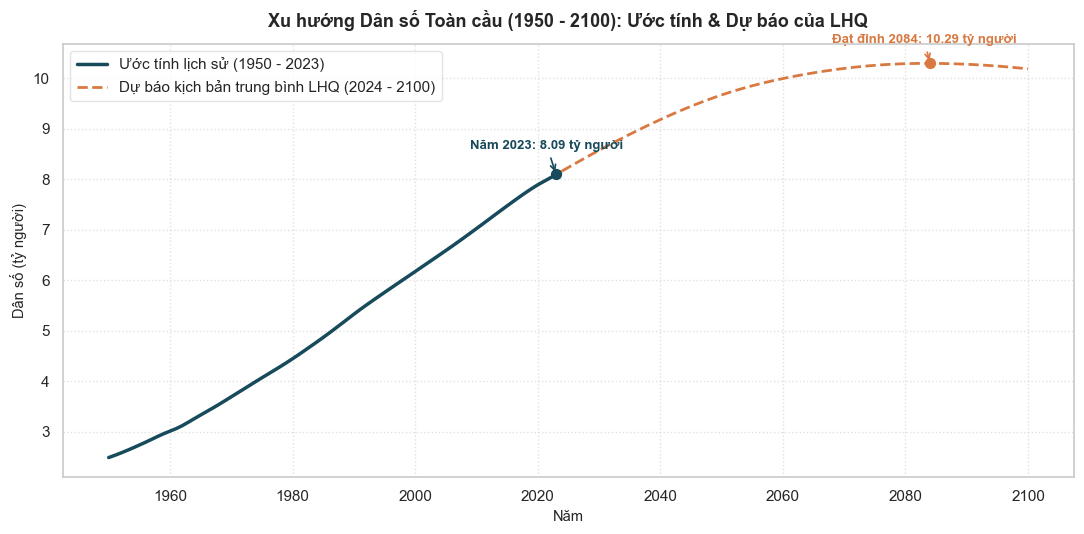

In [4]:
# Lọc dữ liệu dân số của World
world_est = [
    (int(r["Year"]), float(r["Value"]) / 1_000_000_000)
    for r in rows
    if r["Entity"] == "World" and r["Indicator"] == "Population" and r["DataStatus"] == "estimate"
]
world_proj = [
    (int(r["Year"]), float(r["Value"]) / 1_000_000_000)
    for r in rows
    if r["Entity"] == "World" and r["Indicator"] == "Population" and r["DataStatus"] == "projected"
]

world_est.sort()
world_proj.sort()

years_est, vals_est = zip(*world_est)
years_proj, vals_proj = zip(*world_proj)

latest_est_year = years_est[-1]
latest_est_val = vals_est[-1]

max_proj_idx = vals_proj.index(max(vals_proj))
peak_proj_year = years_proj[max_proj_idx]
peak_proj_val = vals_proj[max_proj_idx]

print(f"Dân số thế giới năm {latest_est_year}: {latest_est_val:.2f} tỷ người")
print(f"Dự báo đạt đỉnh năm {peak_proj_year}: {peak_proj_val:.2f} tỷ người")

# Vẽ biểu đồ xu hướng toàn cầu
plt.figure(figsize=(11, 5.5))
plt.plot(years_est, vals_est, color="#174a5b", linewidth=2.5, label="Ước tính lịch sử (1950 - 2023)")

# Nối ước tính với dự báo
plt.plot([latest_est_year, years_proj[0]], [latest_est_val, vals_proj[0]], color="#d97941", linestyle="--", linewidth=2)
plt.plot(years_proj, vals_proj, color="#d97941", linestyle="--", linewidth=2, label="Dự báo kịch bản trung bình LHQ (2024 - 2100)")

# Điểm đánh dấu mốc 2023
plt.scatter([latest_est_year], [latest_est_val], color="#174a5b", s=50, zorder=5)
plt.annotate(
    f"Năm {latest_est_year}: {latest_est_val:.2f} tỷ người",
    xy=(latest_est_year, latest_est_val),
    xytext=(latest_est_year - 14, latest_est_val + 0.5),
    arrowprops=dict(arrowstyle="->", color="#174a5b", lw=1.2),
    fontsize=9.5,
    fontweight="bold",
    color="#174a5b",
)

# Điểm đánh dấu đạt đỉnh
plt.scatter([peak_proj_year], [peak_proj_val], color="#d97941", s=50, zorder=5)
plt.annotate(
    f"Đạt đỉnh {peak_proj_year}: {peak_proj_val:.2f} tỷ người",
    xy=(peak_proj_year, peak_proj_val),
    xytext=(peak_proj_year - 16, peak_proj_val + 0.4),
    arrowprops=dict(arrowstyle="->", color="#d97941", lw=1.2),
    fontsize=9.5,
    fontweight="bold",
    color="#d97941",
)

plt.title("Xu hướng Dân số Toàn cầu (1950 - 2100): Ước tính & Dự báo của LHQ", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Năm", fontsize=10.5)
plt.ylabel("Dân số (tỷ người)", fontsize=10.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", edgecolor="#ddd")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01-global-population-trend.png", dpi=180)
plt.show()

## 4. Biểu đồ 2: Top 10 Quốc gia Đông dân nhất Thế giới (Năm 2023)
Xác định 10 quốc gia có quy mô dân số lớn nhất trong năm ước tính lịch sử gần nhất.

BẢNG TOP 10 QUỐC GIA ĐÔNG DÂN NHẤT (NĂM 2023):
-------------------------------------------------------
 1. India                       1,438,069,597 người ( 1438.1M)
 2. China                       1,422,584,930 người ( 1422.6M)
 3. United States                 343,477,330 người (  343.5M)
 4. Indonesia                     281,190,068 người (  281.2M)
 5. Pakistan                      247,504,505 người (  247.5M)
 6. Nigeria                       227,882,949 người (  227.9M)
 7. Brazil                        211,140,731 người (  211.1M)
 8. Bangladesh                    171,466,986 người (  171.5M)
 9. Russia                        145,440,502 người (  145.4M)
10. Mexico                        129,739,761 người (  129.7M)


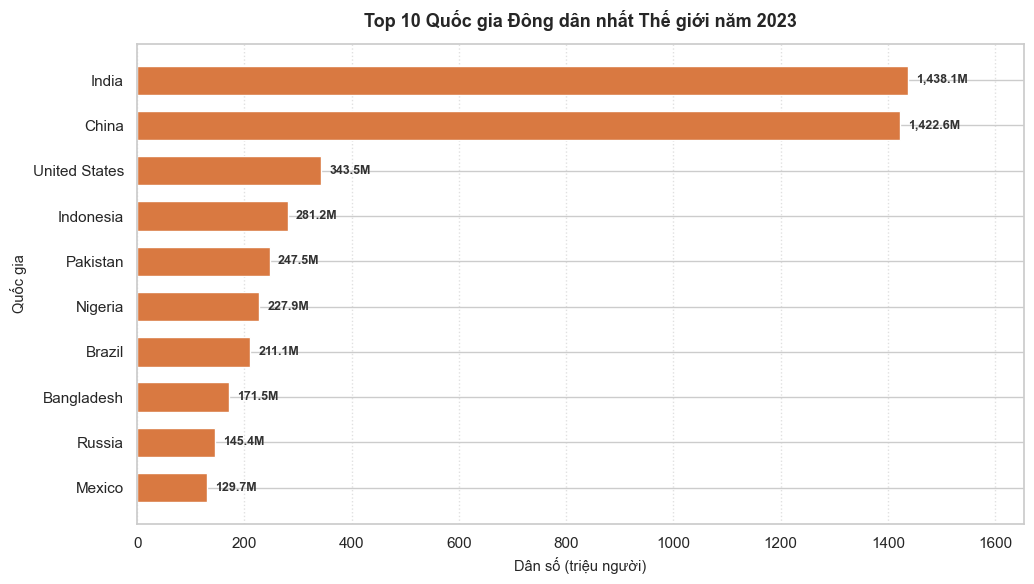

In [5]:
# Lọc dân số các quốc gia năm 2023
pop_2023_countries = [
    (r["Entity"], float(r["Value"]))
    for r in rows
    if r["Indicator"] == "Population"
    and r["DataStatus"] == "estimate"
    and int(r["Year"]) == 2023
    and r["Entity"] in valid_country_entities
]

# Sắp xếp và lấy top 10
top_10 = sorted(pop_2023_countries, key=lambda x: x[1], reverse=True)[:10]

print("BẢNG TOP 10 QUỐC GIA ĐÔNG DÂN NHẤT (NĂM 2023):")
print("-" * 55)
for rank, (name, val) in enumerate(top_10, 1):
    print(f"{rank:2d}. {name:<25} {val:15,.0f} người ({val/1e6:7.1f}M)")

# Chuẩn bị dữ liệu vẽ biểu đồ thanh ngang
top_10_reversed = list(reversed(top_10))
names = [item[0] for item in top_10_reversed]
vals_millions = [item[1] / 1_000_000 for item in top_10_reversed]

plt.figure(figsize=(10.5, 6))
bars = plt.barh(names, vals_millions, color="#d97941", height=0.65)
plt.title("Top 10 Quốc gia Đông dân nhất Thế giới năm 2023", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Dân số (triệu người)", fontsize=10.5)
plt.ylabel("Quốc gia", fontsize=10.5)
plt.grid(axis="x", linestyle=":", alpha=0.6)

for bar, val in zip(bars, vals_millions):
    plt.text(
        val + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.1f}M",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="semibold",
        color="#333",
    )
plt.xlim(0, max(vals_millions) * 1.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02-top-populations.png", dpi=180)
plt.show()

## 5. Biểu đồ 3: Phân phối Tốc độ Tăng trưởng Dân số theo Quốc gia (Năm 2023)
Phân tích tốc độ tăng trưởng hàng năm (%) của 237 quốc gia/vùng lãnh thổ, làm rõ các quốc gia đang suy giảm dân số (tăng trưởng âm) và các quốc gia tăng trưởng dương.

Tổng số quốc gia/vùng lãnh thổ: 237
Tăng trưởng trung bình: +0.96%
Biên độ tăng trưởng: từ -5.40% đến 5.86%
Số quốc gia suy giảm dân số (tăng trưởng âm): 54 (22.8%)
Số quốc gia tiếp tục tăng trưởng dương: 183 (77.2%)


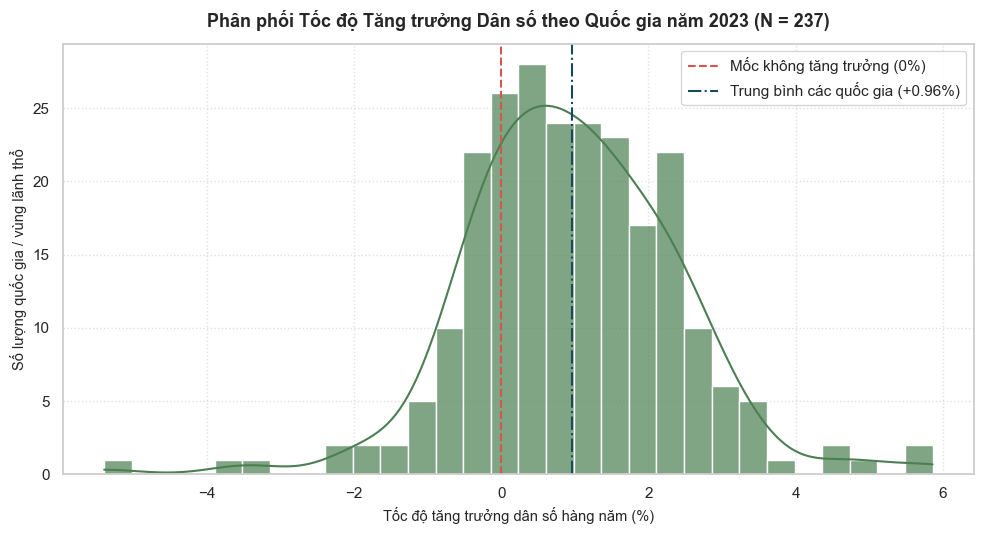

In [6]:
# Lọc tốc độ tăng trưởng dân số năm 2023
growth_2023 = [
    float(r["Value"])
    for r in rows
    if r["Indicator"] == "Population growth rate"
    and r["DataStatus"] == "estimate"
    and int(r["Year"]) == 2023
    and r["Entity"] in valid_country_entities
]

neg_count = sum(1 for v in growth_2023 if v < 0)
pos_count = len(growth_2023) - neg_count
mean_growth = sum(growth_2023) / len(growth_2023)
min_growth = min(growth_2023)
max_growth = max(growth_2023)

print(f"Tổng số quốc gia/vùng lãnh thổ: {len(growth_2023)}")
print(f"Tăng trưởng trung bình: {mean_growth:+.2f}%")
print(f"Biên độ tăng trưởng: từ {min_growth:.2f}% đến {max_growth:.2f}%")
print(f"Số quốc gia suy giảm dân số (tăng trưởng âm): {neg_count} ({neg_count/len(growth_2023)*100:.1f}%)")
print(f"Số quốc gia tiếp tục tăng trưởng dương: {pos_count} ({pos_count/len(growth_2023)*100:.1f}%)")

# Vẽ biểu đồ phân phối
plt.figure(figsize=(10, 5.5))
sns.histplot(growth_2023, bins=30, kde=True, color="#4b7f52", edgecolor="white", alpha=0.7)
plt.axvline(0, color="#d9534f", linestyle="--", linewidth=1.5, label="Mốc không tăng trưởng (0%)")
plt.axvline(mean_growth, color="#174a5b", linestyle="-.", linewidth=1.5, label=f"Trung bình các quốc gia ({mean_growth:+.2f}%)")

plt.title(f"Phân phối Tốc độ Tăng trưởng Dân số theo Quốc gia năm 2023 (N = {len(growth_2023)})", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Tốc độ tăng trưởng dân số hàng năm (%)", fontsize=10.5)
plt.ylabel("Số lượng quốc gia / vùng lãnh thổ", fontsize=10.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03-growth-rate-distribution.png", dpi=180)
plt.show()

## 6. Biểu đồ 4: Tương quan giữa Mức sinh (TFR) và Tốc độ Tăng trưởng Dân số
Khám phá mối tương quan giữa Tổng tỷ suất sinh (Total Fertility Rate - TFR) và Tốc độ tăng trưởng dân số thực tế của các quốc gia trong năm 2023.

Số lượng quan sát cấp quốc gia: 237
Số quốc gia có TFR < 2.1 (dưới mức sinh thay thế): 130 (54.9%)


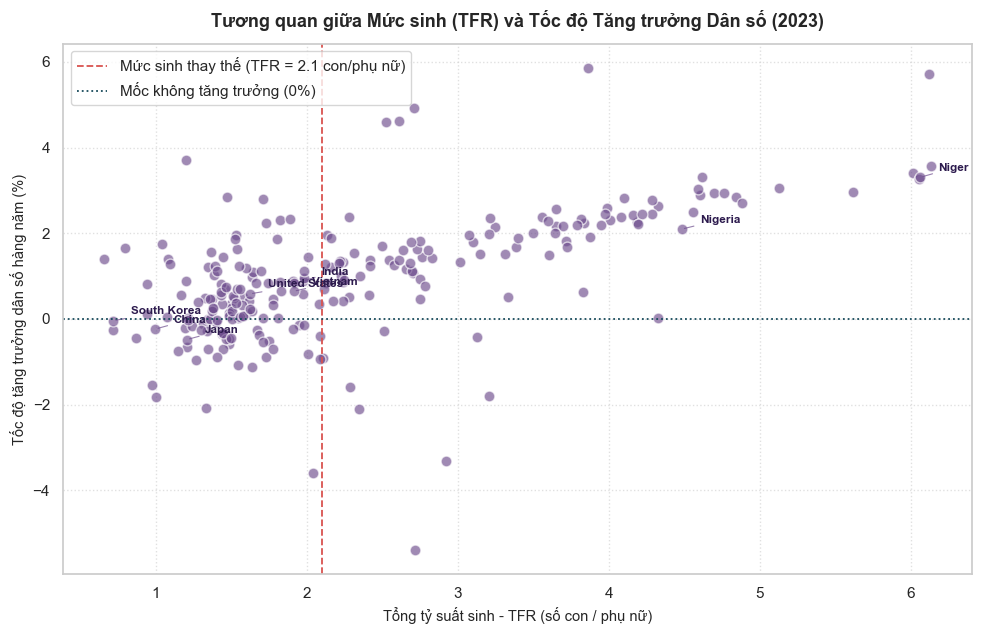

In [7]:
# Ghép cặp TFR và Growth rate năm 2023
tfr_map = {
    r["Entity"]: float(r["Value"])
    for r in rows
    if r["Indicator"] == "Total fertility rate"
    and r["DataStatus"] == "estimate"
    and int(r["Year"]) == 2023
    and r["Entity"] in valid_country_entities
}
growth_map = {
    r["Entity"]: float(r["Value"])
    for r in rows
    if r["Indicator"] == "Population growth rate"
    and r["DataStatus"] == "estimate"
    and int(r["Year"]) == 2023
    and r["Entity"] in valid_country_entities
}

paired_data = [
    (e, tfr_map[e], growth_map[e])
    for e in tfr_map
    if e in growth_map
]

below_replacement = sum(1 for item in paired_data if item[1] < 2.1)
total_pairs = len(paired_data)

print(f"Số lượng quan sát cấp quốc gia: {total_pairs}")
print(f"Số quốc gia có TFR < 2.1 (dưới mức sinh thay thế): {below_replacement} ({below_replacement/total_pairs*100:.1f}%)")

# Vẽ biểu đồ phân tán
plt.figure(figsize=(10, 6.5))
x_vals = [item[1] for item in paired_data]
y_vals = [item[2] for item in paired_data]

plt.scatter(x_vals, y_vals, alpha=0.65, color="#6d4c8d", edgecolors="white", s=60)
plt.axvline(2.1, color="#d9534f", linestyle="--", linewidth=1.3, label="Mức sinh thay thế (TFR = 2.1 con/phụ nữ)")
plt.axhline(0.0, color="#174a5b", linestyle=":", linewidth=1.3, label="Mốc không tăng trưởng (0%)")

# Gán nhãn các quốc gia tiêu biểu
highlight_entities = {"India", "China", "United States", "Nigeria", "South Korea", "Vietnam", "Japan", "Niger"}
for entity, x, y in paired_data:
    if entity in highlight_entities:
        plt.annotate(
            entity,
            xy=(x, y),
            xytext=(x + 0.12, y + 0.15),
            fontsize=8.5,
            fontweight="semibold",
            color="#2d1b4e",
            arrowprops=dict(arrowstyle="-", color="#6d4c8d", lw=0.8, alpha=0.7),
        )

plt.title("Tương quan giữa Mức sinh (TFR) và Tốc độ Tăng trưởng Dân số (2023)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Tổng tỷ suất sinh - TFR (số con / phụ nữ)", fontsize=10.5)
plt.ylabel("Tốc độ tăng trưởng dân số hàng năm (%)", fontsize=10.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04-fertility-growth-scatter.png", dpi=180)
plt.show()

## 7. Biểu đồ 5: Bản đồ nhiệt Dân số (Heatmap) Top 15 Quốc gia Đông dân nhất
Theo dõi sự chuyển dịch quy mô dân số (đơn vị: triệu người) của 15 quốc gia đông dân nhất qua các mốc thời gian: 1990, 2000, 2010, 2020 và 2023.

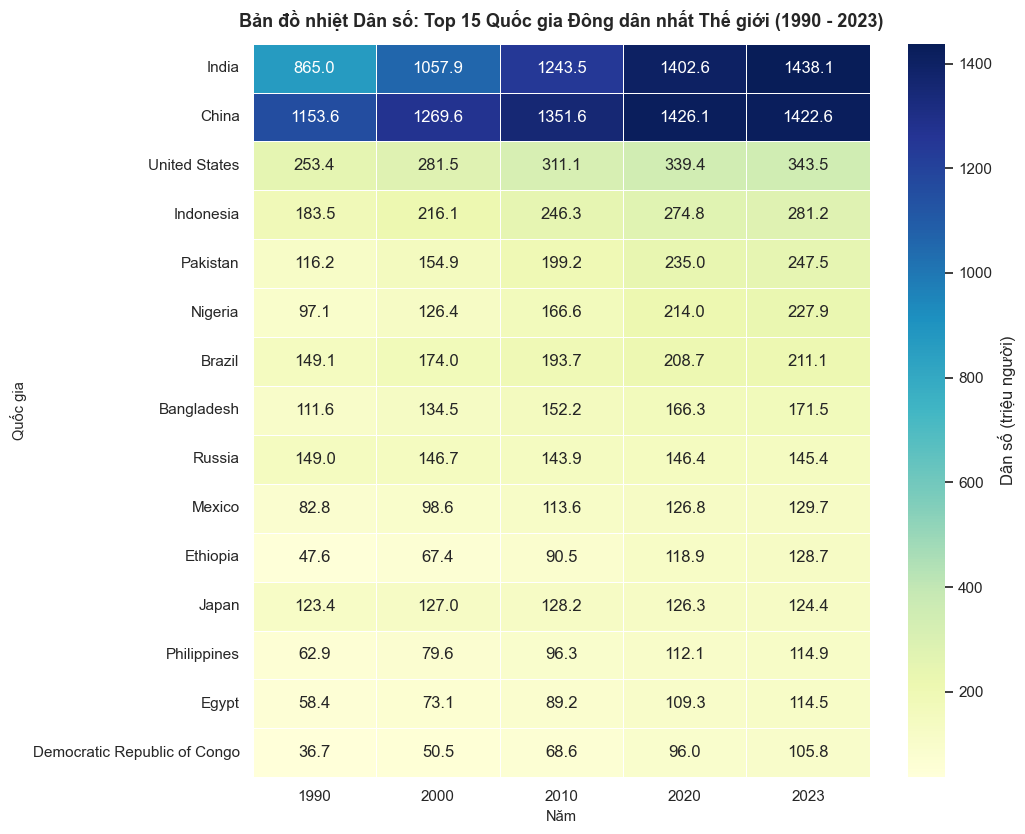

In [8]:
# Chọn Top 15 quốc gia đông dân nhất năm 2023
top_15_names = [
    item[0]
    for item in sorted(pop_2023_countries, key=lambda x: x[1], reverse=True)[:15]
]

milestone_years = [1990, 2000, 2010, 2020, 2023]
matrix = {country: {} for country in top_15_names}

for r in rows:
    if (
        r["Indicator"] == "Population"
        and r["DataStatus"] == "estimate"
        and r["Entity"] in top_15_names
        and int(r["Year"]) in milestone_years
    ):
        matrix[r["Entity"]][int(r["Year"])] = float(r["Value"]) / 1_000_000

# Xây dựng ma trận 2D
heatmap_data = [[matrix[c].get(y, float("nan")) for y in milestone_years] for c in top_15_names]

plt.figure(figsize=(10.5, 8.5))
sns.heatmap(
    heatmap_data,
    xticklabels=[str(y) for y in milestone_years],
    yticklabels=top_15_names,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Dân số (triệu người)"},
    linewidths=0.5,
)
plt.title("Bản đồ nhiệt Dân số: Top 15 Quốc gia Đông dân nhất Thế giới (1990 - 2023)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Năm", fontsize=10.5)
plt.ylabel("Quốc gia", fontsize=10.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05-population-heatmap.png", dpi=180)
plt.show()

## 8. Tổng kết Khám phá Dữ liệu & Xuất Báo cáo Tóm tắt
Tổng hợp các phát hiện chính thành file báo cáo `eda_summary.md` bằng tiếng Việt.

In [9]:
summary_content = [
    "# Tóm tắt Khám phá Dữ liệu Dân số (EDA)",
    "",
    "## 1. Xu hướng Dân số Toàn cầu",
    f"- **Dân số ước tính gần nhất (2023)**: Toàn thế giới đạt **{vals_est[-1]*1e9:,.0f} người** (~{vals_est[-1]:.2f} tỷ người).",
    f"- **Dự báo của LHQ (kịch bản trung bình)**: Dân số toàn cầu dự kiến sẽ đạt đỉnh vào khoảng năm **{peak_proj_year}** với quy mô **{peak_proj_val*1e9:,.0f} người** (~{peak_proj_val:.2f} tỷ người), sau đó bước vào giai đoạn ổn định và giảm nhẹ.",
    "- **Lưu ý chuẩn hóa dữ liệu**: Đường xu hướng toàn cầu lọc riêng thực thể `World` (`OWID_WRL`), tránh bị phóng đại do cộng dồn các nhóm khu vực cấp con.",
    "",
    "## 2. Top 10 Quốc gia Đông dân nhất (Năm 2023)",
    "| Thứ hạng | Quốc gia | Dân số (người) | Quy mô (triệu người) |",
    "| :---: | :--- | :---: | :---: |",
]

for idx, (entity, val) in enumerate(top_10, 1):
    summary_content.append(f"| {idx} | {entity} | {val:,.0f} | {val / 1e6:,.1f}M |")

summary_content.extend([
    "",
    "## 3. Động lực Tăng trưởng & Xu hướng Phân hóa Dân số",
    f"- **Năm đánh giá**: 2023 trên tổng số {len(growth_2023)} quốc gia và vùng lãnh thổ.",
    f"- **Biên độ tăng trưởng**: Thấp nhất {min_growth:.2f}% đến Cao nhất {max_growth:.2f}%.",
    f"- **Quốc gia suy giảm dân số (tăng trưởng âm)**: Có **{neg_count}** quốc gia/vùng lãnh thổ đang suy giảm dân số (ví dụ: Ukraine, Bulgaria, Nhật Bản, Hàn Quốc).",
    f"- **Quốc gia tiếp tục tăng trưởng**: Có **{pos_count}** quốc gia/vùng lãnh thổ duy trì tăng trưởng dương, tập trung cao nhất tại khu vực Châu Phi cận Sahara.",
    "",
    "## 4. Tương quan giữa Mức sinh (TFR) và Tốc độ Tăng trưởng Dân số",
    f"- Phân tích trên **{total_pairs}** cặp quan sát cấp quốc gia trong năm 2023.",
    f"- **Dưới mức sinh thay thế (TFR < 2.1)**: Có tới **{below_replacement}** trên {total_pairs} quốc gia ({below_replacement / total_pairs * 100:.1f}%) có mức sinh thấp hơn mức sinh thay thế cần thiết để duy trì quy mô dân số ổn định.",
    "- **Tương quan**: Tồn tại mối tương quan thuận mạnh mẽ giữa tổng tỷ suất sinh và tốc độ tăng trưởng dân số thực tế.",
    "",
    "## 5. Định hướng cho Bước Mô hình hóa (Modeling) và Dashboard Tableau",
    "1. **Phân cấp Quốc gia và Vùng tổng hợp**: Khi làm Dashboard Tableau, cần phân tách rõ bộ lọc giữa cấp Quốc gia và cấp Châu lục/Nhóm thu nhập để người dùng không bị tính lặp số liệu.",
    "2. **Cấu trúc Dòng thời gian kép**: Phân định rành mạch giữa dữ liệu quan sát lịch sử (`estimate`: 1950 - 2023) và dữ liệu dự phóng (`projected`: 2024 - 2100).",
    "3. **Gắn nhãn Nguy cơ Suy giảm Dân số (Depopulation Risk)**: Sử dụng mô hình phân loại Logistic Regression để gắn cờ các quốc gia có nguy cơ suy giảm dân số dựa trên mức sinh thấp kéo dài và tỷ lệ tăng trưởng âm.",
])

summary_file = OUTPUT_DIR / "eda_summary.md"
summary_file.write_text("\n".join(summary_content) + "\n", encoding="utf-8")
print(f"Đã lưu báo cáo tóm tắt tại: {summary_file}")
print("Hoàn tất quy trình EDA!")

Đã lưu báo cáo tóm tắt tại: /Users/phitaan/Documents/WORKSPACE/TTDLTQ/PROJECT CUỐI KỲ - BASIC/reports/eda/eda_summary.md
Hoàn tất quy trình EDA!
